In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.interpolate import interp1d

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
mags = np.array([4., 5., 6., 7.] + np.arange(7.5, 18.5, 0.5).tolist())

# South
# radius vs magnitude relation from Mehdi
radii_south = [700., 500., 350., 260., 200.,
               180., 170., 120., 100., 75., 65.,
               55., 50., 40., 30., 25., 22.,
               19., 18., 14., 11., 10.0, 7.5,
               6.0, 5.5, 4.2]
log_radii = np.log10(radii_south)
radius_log_south = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
radius_south = lambda mags: np.maximum(10**radius_log_south(mags), 1630. * 1.396**(-mags))

# North
# radius vs magnitude relation from Mehdi
radii_north = np.array([690., 590., 550., 510., 310.,
                        270., 260., 250., 150., 120., 95.,
                        85., 70., 65., 40., 35.,
                        30., 25., 20., 18., 15.,
                        12., 10., 10., 8.0, 7.0])
log_radii = np.log10(radii_north)
radius_log_north = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
radius_north = lambda mags: np.maximum(10**radius_log_north(mags), 1630. * 1.396**(-mags))

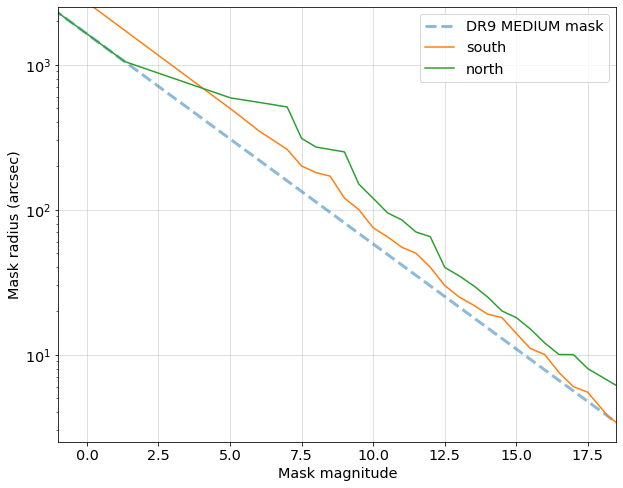

In [4]:
mags_plot = np.linspace(-2, 19, 1000)
dr9_radius = 1630 * 1.396**(-mags_plot)

plt.figure(figsize=(10, 8))
plt.plot(mags_plot, dr9_radius, label='DR9 MEDIUM mask', lw=3, ls='--', alpha=0.5)
plt.plot(mags_plot, radius_south(mags_plot), label='south')
plt.plot(mags_plot, radius_north(mags_plot), label='north')
plt.yscale('log')
plt.grid(alpha=0.5)
plt.xlabel('Mask magnitude')
plt.ylabel('Mask radius (arcsec)')
# plt.axhline(60, lw=1, ls='--', color='k', label='maximum radius')
plt.axis([-1, 18.5, 2.5, 2500])
plt.legend()
plt.show()